In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.base import clone

import warnings
warnings.filterwarnings("ignore")

In [2]:
columns = ["label", "lepton_pT", "lepton_eta", "lepton_phi", "missing_energy_magnitude", "missing_energy_phi", "jet_1_pt", "jet_1_eta", 
           "jet_1_phi", "jet_1_b_tag", "jet_2_pt", "jet_2_eta", "jet_2_phi", "jet_2_b_tag", "jet_3_pt", "jet_3_eta", "jet_3_phi", 
           "jet_3_b_tag", "jet_4_pt", "jet_4_eta", "jet_4_phi", "jet_4_b_tag", "m_jj", "m_jjj", "m_lv", "m_jlv", "m_bb", "m_wbb", "m_wwbb" ]

In [3]:
df = pd.read_csv("HIGGS.csv", compression="gzip", header=None, names=columns)

In [4]:
df.head()

,label,lepton_pT,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet_1_pt,jet_1_eta,jet_1_phi,jet_1_b_tag,...,jet_4_eta,jet_4_phi,jet_4_b_tag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
0,1.0,0.869293,-0.635082,0.225690,0.327470,-0.689993,0.754202,-0.248573,-1.092064,0.000000,...,-0.010455,-0.045767,3.101961,1.353760,0.979563,0.978076,0.920005,0.721657,0.988751,0.876678
1,1.0,0.907542,0.329147,0.359412,1.497970,-0.313010,1.095531,-0.557525,-1.588230,2.173076,...,-1.138930,-0.000819,0.000000,0.302220,0.833048,0.985700,0.978098,0.779732,0.992356,0.798343
2,1.0,0.798835,1.470639,-1.635975,0.453773,0.425629,1.104875,1.282322,1.381664,0.000000,...,1.128848,0.900461,0.000000,0.909753,1.108330,0.985692,0.951331,0.803252,0.865924,0.780118
3,0.0,1.344385,-0.876626,0.935913,1.992050,0.882454,1.786066,-1.646778,-0.942383,0.000000,...,-0.678379,-1.360356,0.000000,0.946652,1.028704,0.998656,0.728281,0.869200,1.026736,0.957904
4,1.0,1.105009,0.321356,1.522401,0.882808,-1.205349,0.681466,-1.070464,-0.921871,0.000000,...,-0.373566,0.113041,0.000000,0.755856,1.361057,0.986610,0.838085,1.133295,0.872245,0.808487


In [ ]:
df.shape

(11000000, 29)

In [6]:
df = df.sample(n=100000, random_state=23)

In [7]:
df.shape

(100000, 29)

In [8]:
df["label"].value_counts()

label
1.0    53134
0.0    46866
Name: count, dtype: int64

In [9]:
df.isnull().sum()

label                       0
lepton_pT                   0
lepton_eta                  0
lepton_phi                  0
missing_energy_magnitude    0
missing_energy_phi          0
jet_1_pt                    0
jet_1_eta                   0
jet_1_phi                   0
jet_1_b_tag                 0
jet_2_pt                    0
jet_2_eta                   0
jet_2_phi                   0
jet_2_b_tag                 0
jet_3_pt                    0
jet_3_eta                   0
jet_3_phi                   0
jet_3_b_tag                 0
jet_4_pt                    0
jet_4_eta                   0
jet_4_phi                   0
jet_4_b_tag                 0
m_jj                        0
m_jjj                       0
m_lv                        0
m_jlv                       0
m_bb                        0
m_wbb                       0
m_wwbb                      0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 8072155 to 3132601
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   label                     100000 non-null  float64
 1   lepton_pT                 100000 non-null  float64
 2   lepton_eta                100000 non-null  float64
 3   lepton_phi                100000 non-null  float64
 4   missing_energy_magnitude  100000 non-null  float64
 5   missing_energy_phi        100000 non-null  float64
 6   jet_1_pt                  100000 non-null  float64
 7   jet_1_eta                 100000 non-null  float64
 8   jet_1_phi                 100000 non-null  float64
 9   jet_1_b_tag               100000 non-null  float64
 10  jet_2_pt                  100000 non-null  float64
 11  jet_2_eta                 100000 non-null  float64
 12  jet_2_phi                 100000 non-null  float64
 13  jet_2_b_tag               100000 non-null 

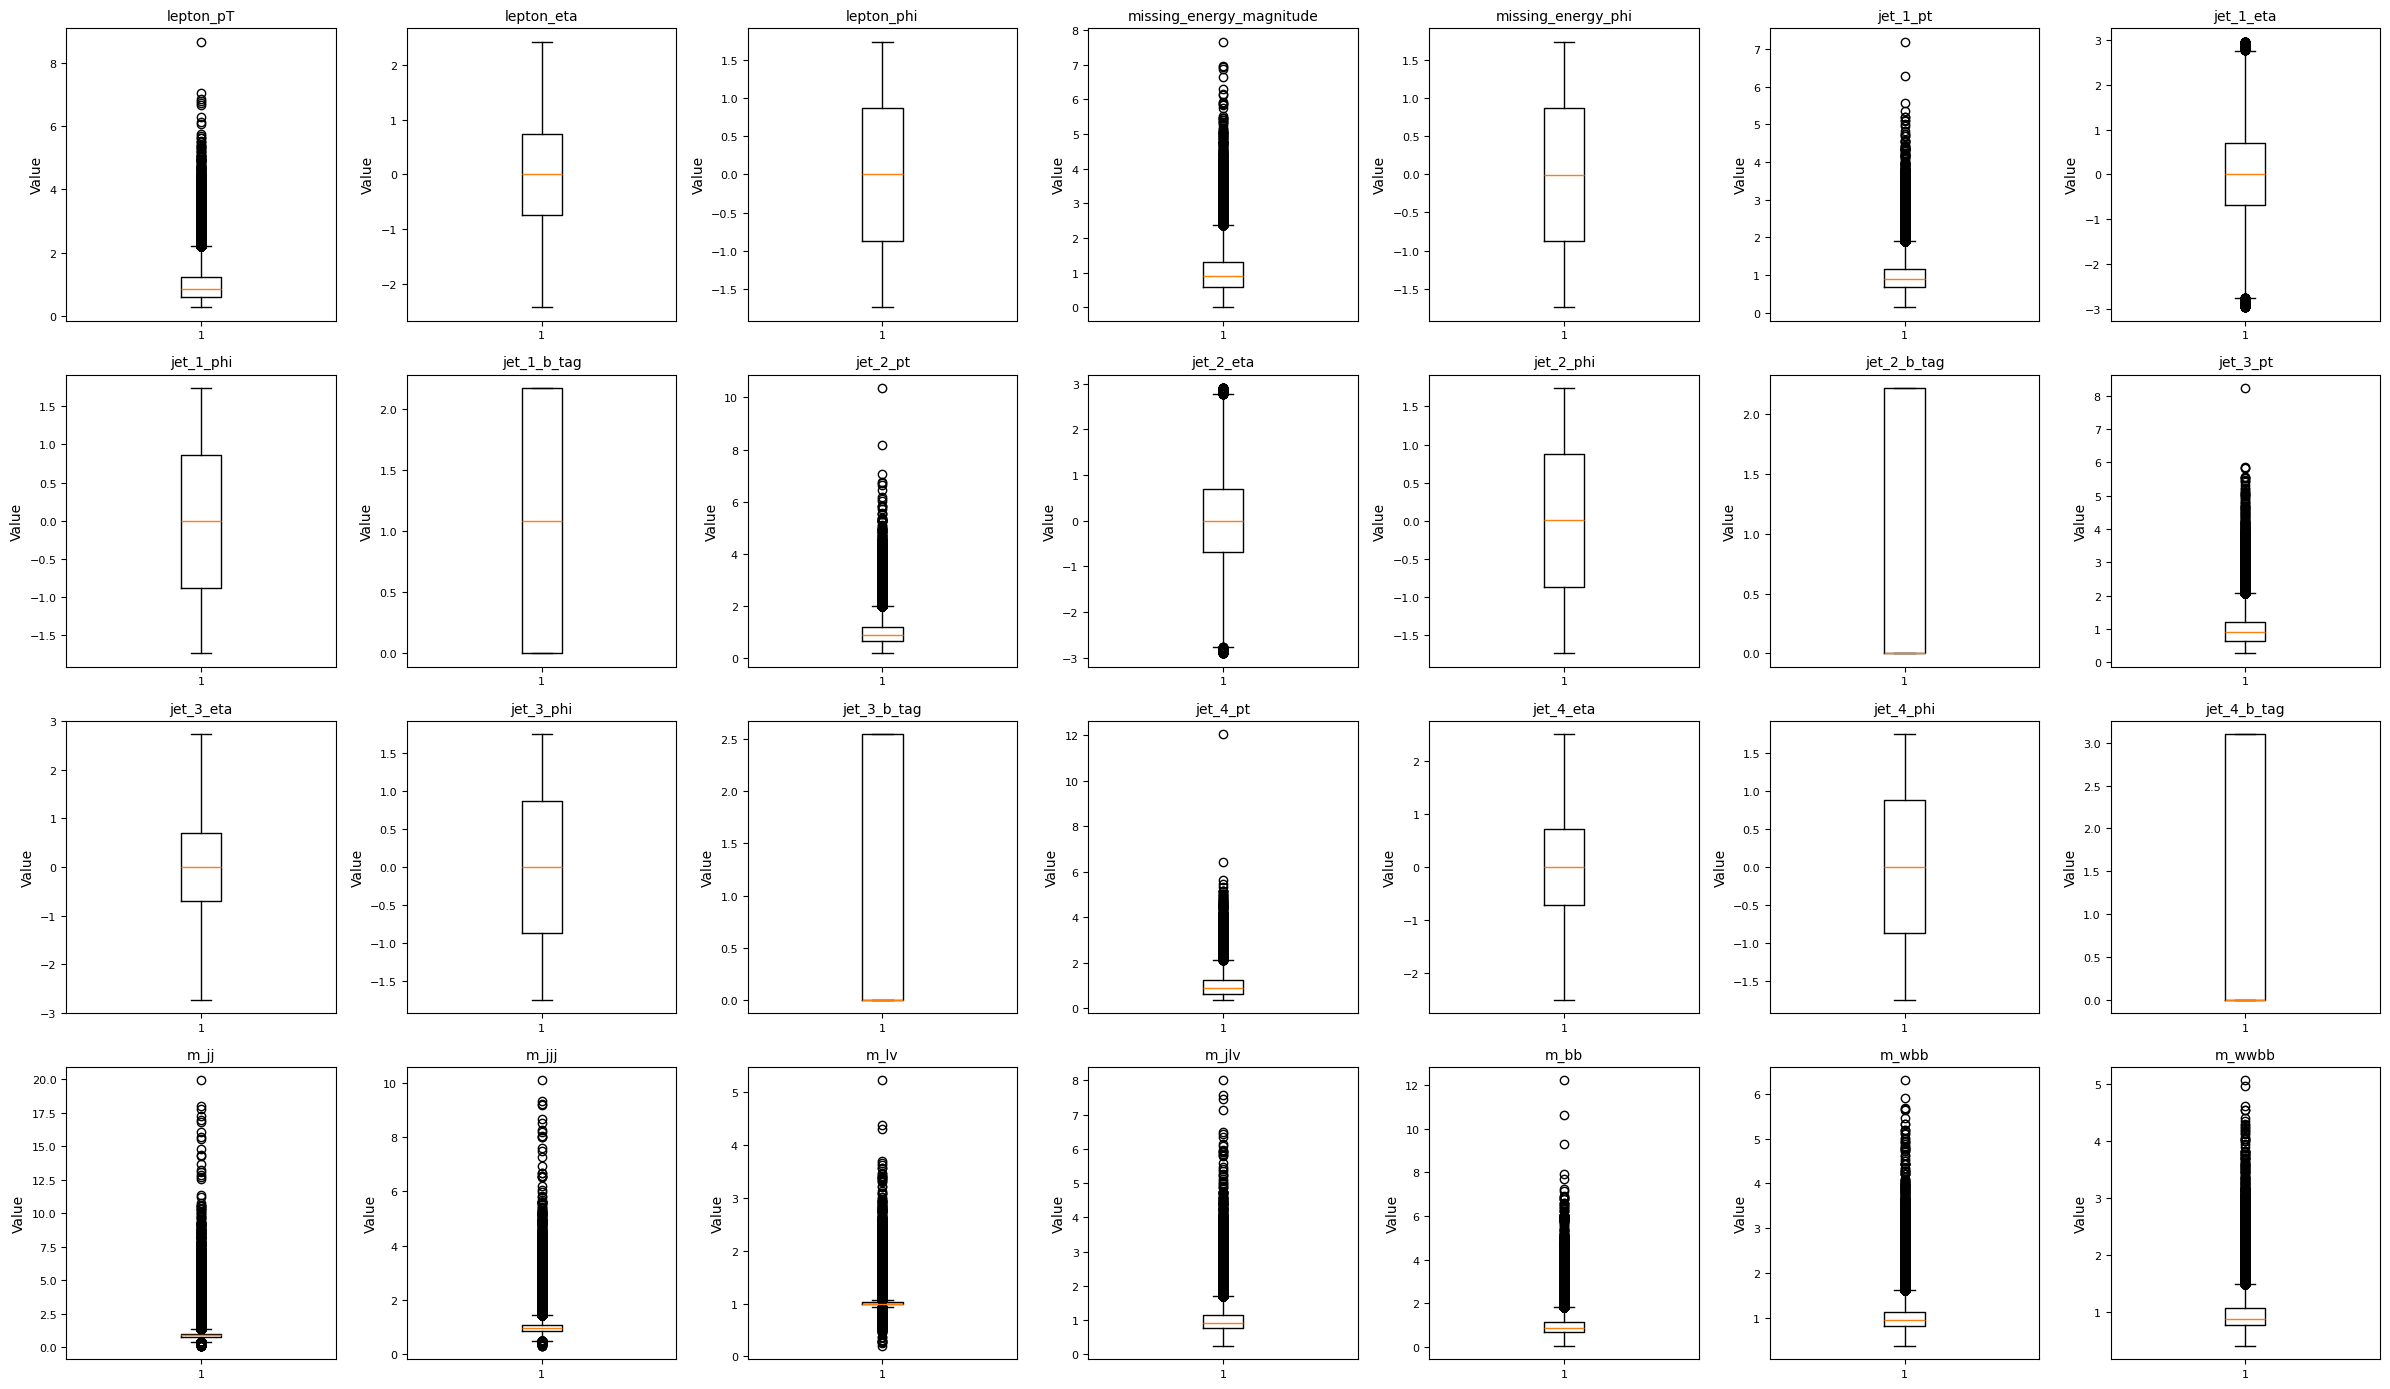

In [11]:
feature_cols = [col for col in df.columns if col != "label"]

fig, axes = plt.subplots(4, 7, figsize=(24, 14))
axes = axes.ravel()

for i, col in enumerate(feature_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, showfliers=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("Value")
    axes[i].tick_params(axis="x", labelsize=8)
    axes[i].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

In [12]:
Q1 = df[feature_cols].quantile(0.25)
Q3 = df[feature_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = ~((df[feature_cols] < lower_bound) | 
         (df[feature_cols] > upper_bound)).any(axis=1)

df_clean = df[mask].reset_index(drop=True)

print("Before removing outliers:", df.shape)
print("After removing outliers:", df_clean.shape)
print("Removed rows:", df.shape[0] - df_clean.shape[0])

Before removing outliers: (100000, 29)
After removing outliers: (53028, 29)
Removed rows: 46972


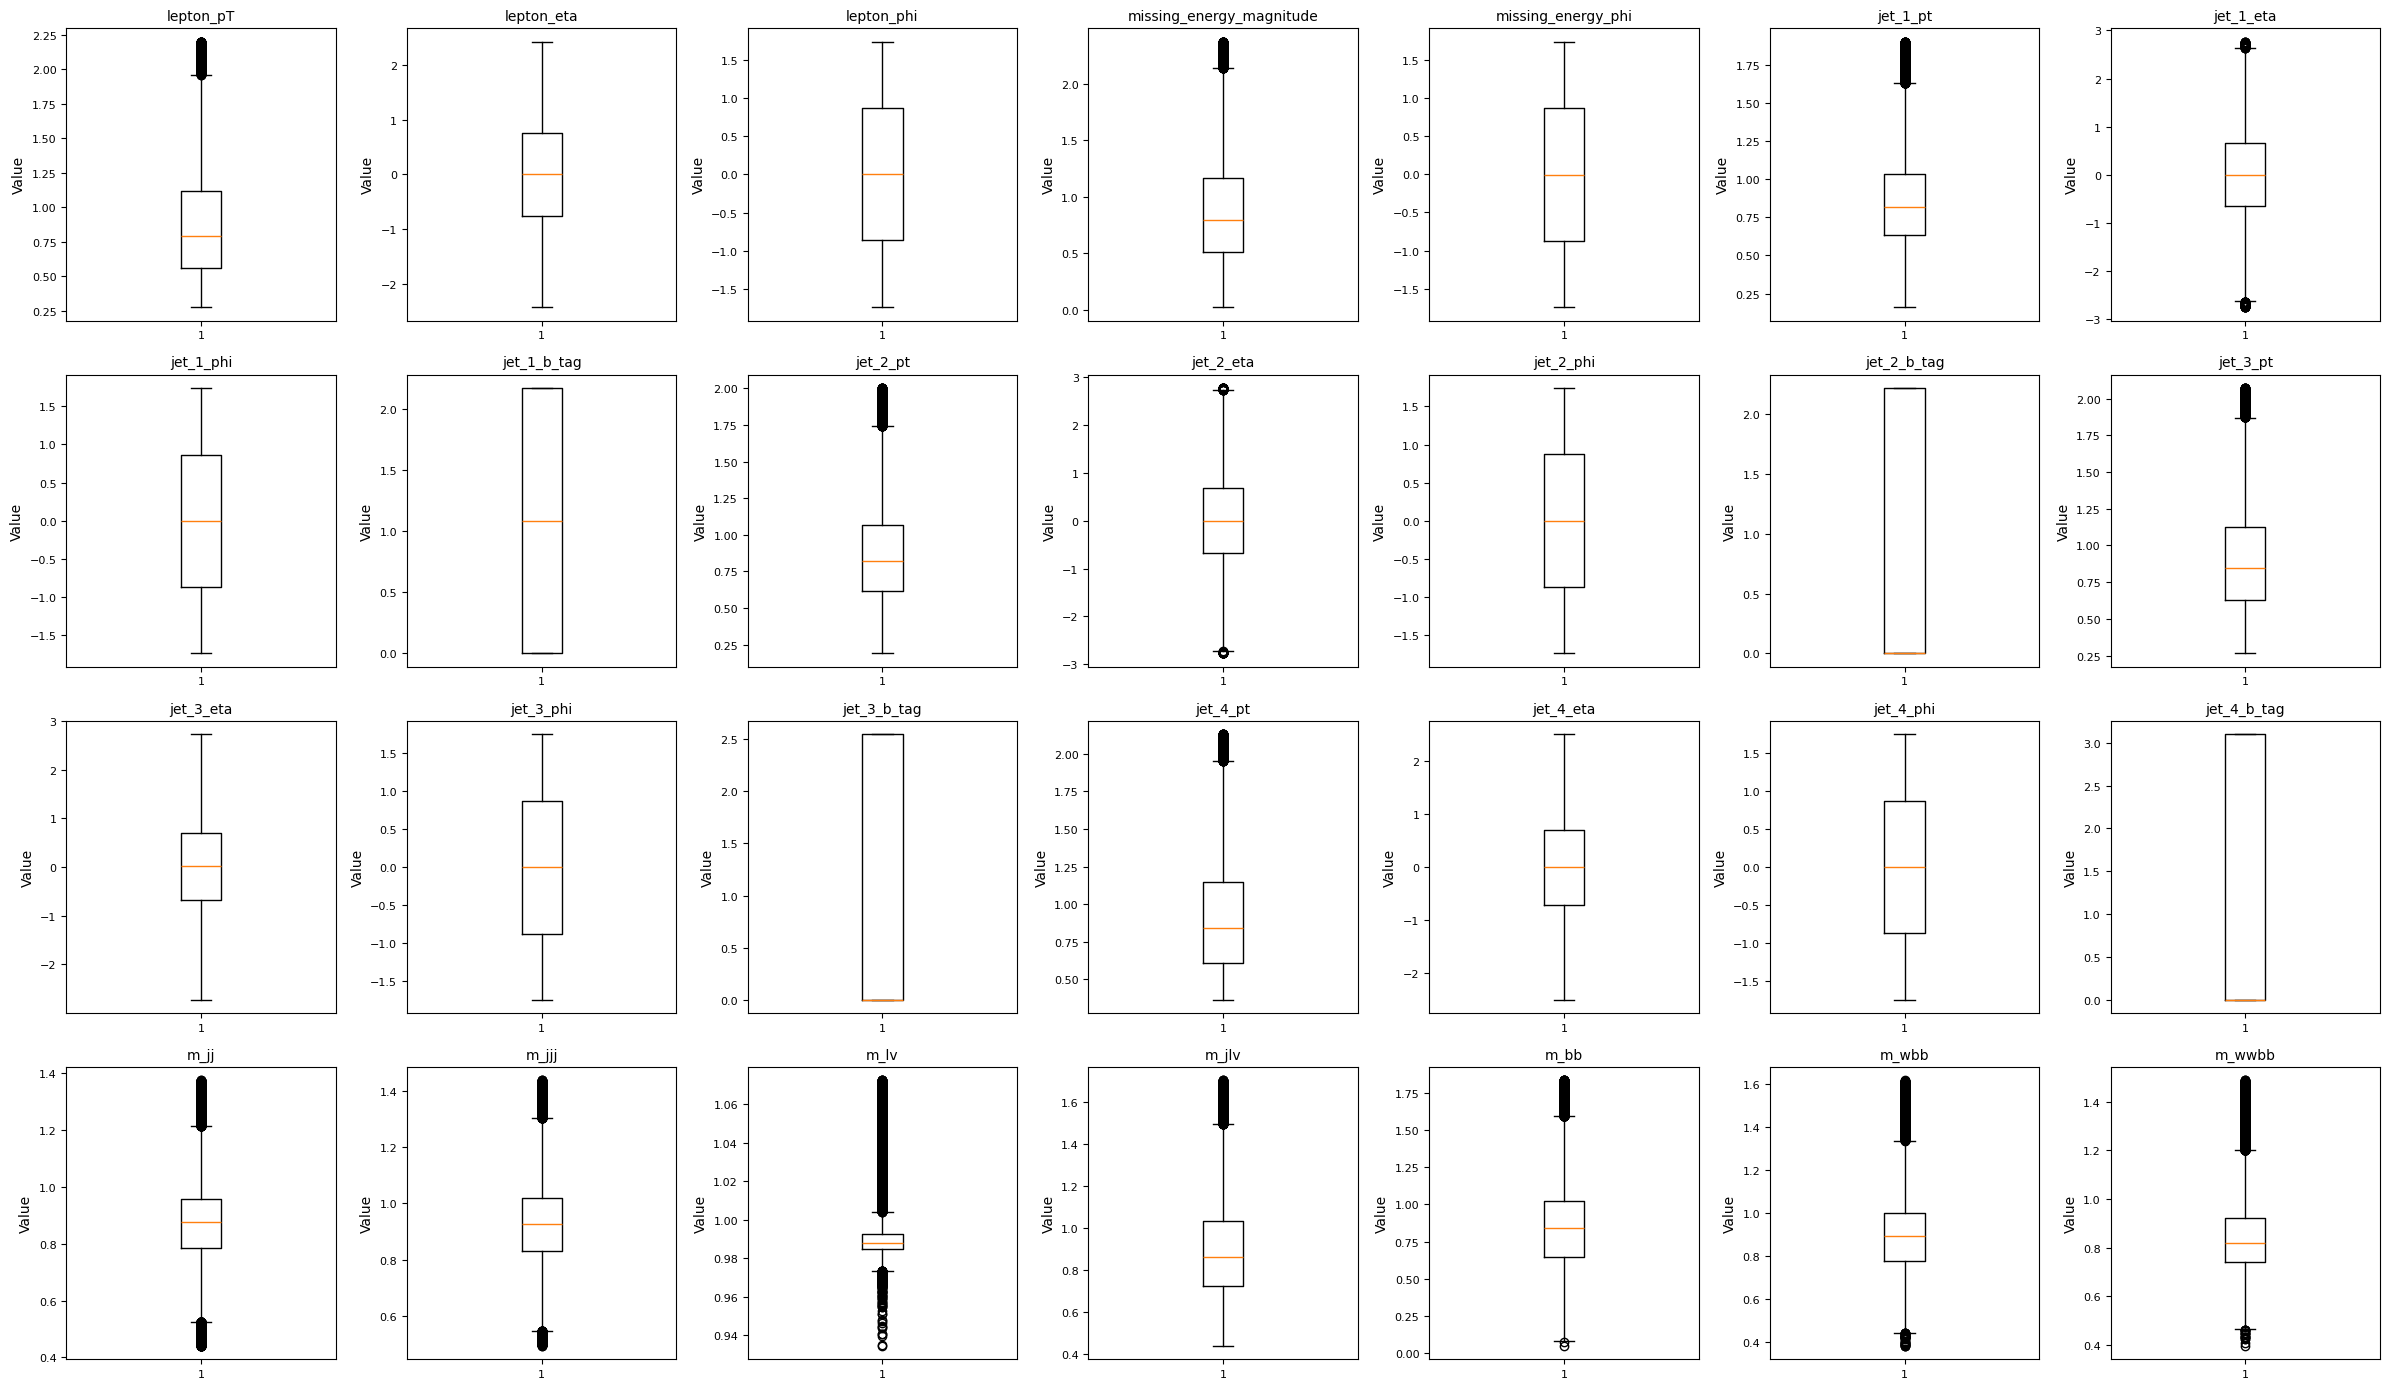

In [13]:
fig, axes = plt.subplots(4, 7, figsize=(24, 14))
axes = axes.ravel()

for i, col in enumerate(feature_cols):
    axes[i].boxplot(df_clean[col].dropna(), vert=True, showfliers=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("Value")
    axes[i].tick_params(axis="x", labelsize=8)
    axes[i].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

In [14]:
df_clean.head()

,label,lepton_pT,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet_1_pt,jet_1_eta,jet_1_phi,jet_1_b_tag,...,jet_4_eta,jet_4_phi,jet_4_b_tag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
0,0.0,0.811645,-0.394512,0.413233,1.595672,-0.379156,0.807701,-0.470385,-1.639787,0.0,...,2.414727,1.326633,0.000000,0.925771,0.965756,1.031578,0.727410,1.164591,0.793240,0.788300
1,0.0,0.308553,0.676854,-1.321368,1.602268,0.078299,0.864772,1.902206,-0.088642,0.0,...,0.884830,0.979813,3.101961,1.147091,1.011708,0.990162,0.888197,0.736976,0.971663,0.912550
2,1.0,1.118735,0.178182,-0.389199,0.719999,0.546758,0.932562,-1.248705,-1.117011,0.0,...,-1.150590,1.474795,0.000000,0.992635,1.115242,0.987779,0.801517,0.729147,0.873164,0.839243
3,0.0,0.475641,-1.385038,-0.164480,0.605767,-0.493598,1.417622,-1.314060,0.974753,0.0,...,1.050562,-0.849282,3.101961,0.860253,0.946567,0.999723,0.839324,1.402502,1.435798,1.187828
4,1.0,0.633577,0.889179,-0.529579,0.623481,0.564442,0.986793,0.911976,1.729257,0.0,...,-0.844943,-0.540748,3.101961,0.803940,1.042489,0.986459,0.676626,0.923479,0.892967,0.772736


In [15]:
def flowchart_A(df):

    X = df.drop("label", axis=1)
    y = df["label"].astype(int)

    feature_names = X.columns

    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    results = []

    models = {
        "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),

        "SVM": SVC(C=1, kernel="rbf", probability=True),

        "MLP": MLPClassifier(hidden_layer_sizes=(50,), activation="relu", max_iter=300, random_state=42),

        "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1)
    }


    feature_method = "anova"

    for outer_fold, (train_index, test_index) in enumerate(outer_cv.split(X, y), start=1):

        print("\nOuter Fold:", outer_fold)

        X_train_val = X.iloc[train_index]
        X_test = X.iloc[test_index]

        y_train_val = y.iloc[train_index]
        y_test = y.iloc[test_index]

        for model_name, base_model in models.items():

            print("Model:", model_name)

            inner_scores = []

            for inner_train_index, inner_val_index in inner_cv.split(X_train_val, y_train_val):

                X_inner_train = X_train_val.iloc[inner_train_index]
                X_inner_val = X_train_val.iloc[inner_val_index]

                y_inner_train = y_train_val.iloc[inner_train_index]
                y_inner_val = y_train_val.iloc[inner_val_index]

                scaler = MinMaxScaler()
                X_inner_train_scaled = scaler.fit_transform(X_inner_train)
                X_inner_val_scaled = scaler.transform(X_inner_val)

                selector = SelectKBest(score_func=f_classif, k=15)

                X_inner_train_selected = selector.fit_transform(X_inner_train_scaled, y_inner_train)
                X_inner_val_selected = selector.transform(X_inner_val_scaled)

                model = clone(base_model)
                model.fit(X_inner_train_selected, y_inner_train)

                y_val_pred = model.predict(X_inner_val_selected)
                acc = accuracy_score(y_inner_val, y_val_pred)

                inner_scores.append(acc)

            mean_inner_acc = np.mean(inner_scores)

            print(feature_method, "inner accuracy:", mean_inner_acc)

            scaler = MinMaxScaler()
            X_train_val_scaled = scaler.fit_transform(X_train_val)
            X_test_scaled = scaler.transform(X_test)

            selector = SelectKBest(score_func=f_classif, k=15)

            X_train_val_selected = selector.fit_transform(X_train_val_scaled, y_train_val)
            X_test_selected = selector.transform(X_test_scaled)

            selected_features = feature_names[selector.get_support()]

            final_model = clone(base_model)
            final_model.fit(X_train_val_selected, y_train_val)

            y_pred = final_model.predict(X_test_selected)

            if hasattr(final_model, "predict_proba"):
                y_score = final_model.predict_proba(X_test_selected)[:, 1]
            else:
                y_score = final_model.decision_function(X_test_selected)

            acc = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, zero_division=0)
            recall = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            auc = roc_auc_score(y_test, y_score)

            results.append({"outer_fold": outer_fold, "model": model_name, "feature_selection": feature_method,
                "inner_accuracy": mean_inner_acc, "test_accuracy": acc, "precision": precision,
                "recall": recall, "f1_score": f1, "roc_auc": auc, "selected_features": list(selected_features)})

            print("Test Accuracy:", acc)
            print("----------------------")

    results_df = pd.DataFrame(results)

    return results_df

In [16]:
results_A = flowchart_A(df_clean)
results_A


Outer Fold: 1
Model: KNN
anova inner accuracy: 0.6459857765101068
Test Accuracy: 0.6502922873844993
----------------------
Model: SVM
anova inner accuracy: 0.6962897434843347
Test Accuracy: 0.7032811616066378
----------------------
Model: MLP
anova inner accuracy: 0.7121304857813612
Test Accuracy: 0.7207241184235339
----------------------
Model: XGBoost
anova inner accuracy: 0.7105982597108045
Test Accuracy: 0.7190269658683764
----------------------

Outer Fold: 2
Model: KNN
anova inner accuracy: 0.6441233657344944
Test Accuracy: 0.6450122572128983
----------------------
Model: SVM
anova inner accuracy: 0.6984582367234875
Test Accuracy: 0.6940411088063361
----------------------
Model: MLP
anova inner accuracy: 0.7152185500506266
Test Accuracy: 0.7133697906845182
----------------------
Model: XGBoost
anova inner accuracy: 0.7110461566426981
Test Accuracy: 0.7119554968885536
----------------------

Outer Fold: 3
Model: KNN
anova inner accuracy: 0.6336099573164605
Test Accuracy: 0.643126

,outer_fold,model,feature_selection,inner_accuracy,test_accuracy,precision,recall,f1_score,roc_auc,selected_features
0,1,KNN,anova,0.645986,0.650292,0.669672,0.706870,0.687768,0.694039,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
1,1,SVM,anova,0.696290,0.703281,0.701655,0.792352,0.744250,0.766878,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
2,1,MLP,anova,0.712130,0.720724,0.756417,0.718983,0.737225,0.793977,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
3,1,XGBoost,anova,0.710598,0.719027,0.737003,0.753071,0.744950,0.792485,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
4,2,KNN,anova,0.644123,0.645012,0.663317,0.707958,0.684911,0.686714,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
5,2,SVM,anova,0.698458,0.694041,0.695995,0.778720,0.735037,0.757338,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
6,2,MLP,anova,0.715219,0.713370,0.728791,0.755017,0.741672,0.782510,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
7,2,XGBoost,anova,0.711046,0.711955,0.732548,0.742561,0.737520,0.781362,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
8,3,KNN,anova,0.633610,0.643127,0.661696,0.706228,0.683237,0.681360,"[missing_energy_magnitude, jet_1_pt, jet_1_phi..."
9,3,SVM,anova,0.696549,0.700453,0.706031,0.771626,0.737373,0.764975,"[missing_energy_magnitude, jet_1_pt, jet_1_phi..."


In [17]:
top_5_results_A = results_A.sort_values("roc_auc", ascending=False).head(5)
top_5_results_A

,outer_fold,model,feature_selection,inner_accuracy,test_accuracy,precision,recall,f1_score,roc_auc,selected_features
14,4,MLP,anova,0.710864,0.726638,0.759459,0.729365,0.744108,0.797644,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
15,4,XGBoost,anova,0.711548,0.723904,0.740185,0.760166,0.750043,0.796407,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
2,1,MLP,anova,0.712130,0.720724,0.756417,0.718983,0.737225,0.793977,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
3,1,XGBoost,anova,0.710598,0.719027,0.737003,0.753071,0.744950,0.792485,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
11,3,XGBoost,anova,0.708665,0.719687,0.739956,0.748789,0.744346,0.790400,"[missing_energy_magnitude, jet_1_pt, jet_1_phi..."


In [18]:
def flowchart_B(df):

    X = df.drop("label", axis=1)
    y = df["label"].astype(int)

    feature_names = X.columns

    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    results = []

    base_models = {
        "KNN": KNeighborsClassifier(n_jobs=-1),
        "SVM": SVC(probability=True),
        "MLP": MLPClassifier(max_iter=300, random_state=42),
        "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1)
    }

    param_grids = {
        "KNN": [{"n_neighbors": 3}, {"n_neighbors": 4}, {"n_neighbors": 5}, {"n_neighbors": 6}, {"n_neighbors": 7},
            {"n_neighbors": 8}, {"n_neighbors": 9}, {"n_neighbors": 10}, {"n_neighbors": 11}],

        "SVM": [{"C": 0.1, "kernel": "linear"}, {"C": 0.1, "kernel": "rbf"}, {"C": 1, "kernel": "linear"},
            {"C": 1, "kernel": "rbf"}, {"C": 10, "kernel": "linear"}, {"C": 10, "kernel": "rbf"}],

        "MLP": [{"hidden_layer_sizes": (50,), "activation": "relu"}, {"hidden_layer_sizes": (50,), "activation": "tanh"},
            {"hidden_layer_sizes": (100,), "activation": "relu"}, {"hidden_layer_sizes": (100,), "activation": "tanh"}],

        "XGBoost": [{}]
    }

    feature_method = "anova"

    for outer_fold, (train_index, test_index) in enumerate(outer_cv.split(X, y), start=1):

        print("\nOuter Fold:", outer_fold)

        X_train_val = X.iloc[train_index]
        X_test = X.iloc[test_index]

        y_train_val = y.iloc[train_index]
        y_test = y.iloc[test_index]

        scaler = MinMaxScaler()
        X_train_val_scaled = scaler.fit_transform(X_train_val)
        X_test_scaled = scaler.transform(X_test)

        selector = SelectKBest(score_func=f_classif, k=15)

        X_train_val_selected = selector.fit_transform(X_train_val_scaled, y_train_val)
        X_test_selected = selector.transform(X_test_scaled)

        selected_features = feature_names[selector.get_support()]

        for model_name in base_models:

            print("Model:", model_name)

            best_score = 0
            best_params = None

            for params in param_grids[model_name]:

                inner_scores = []

                for inner_train_index, inner_val_index in inner_cv.split(X_train_val, y_train_val):

                    X_inner_train = X_train_val.iloc[inner_train_index]
                    X_inner_val = X_train_val.iloc[inner_val_index]

                    y_inner_train = y_train_val.iloc[inner_train_index]
                    y_inner_val = y_train_val.iloc[inner_val_index]

                    inner_scaler = MinMaxScaler()
                    X_inner_train_scaled = inner_scaler.fit_transform(X_inner_train)
                    X_inner_val_scaled = inner_scaler.transform(X_inner_val)

                    inner_selector = SelectKBest(score_func=f_classif, k=15)
                    X_inner_train_selected = inner_selector.fit_transform(X_inner_train_scaled, y_inner_train)
                    X_inner_val_selected = inner_selector.transform(X_inner_val_scaled)

                    model = clone(base_models[model_name])
                    model.set_params(**params)

                    model.fit(X_inner_train_selected, y_inner_train)

                    y_val_pred = model.predict(X_inner_val_selected)
                    acc = accuracy_score(y_inner_val, y_val_pred)

                    inner_scores.append(acc)

                mean_acc = np.mean(inner_scores)
                print(params, "inner accuracy:", mean_acc)

                if mean_acc > best_score:
                    best_score = mean_acc
                    best_params = params

            if model_name == "XGBoost":
                print("Best params: default")
            else:
                print("Best params:", best_params)

            final_model = clone(base_models[model_name])
            final_model.set_params(**best_params)

            final_model.fit(X_train_val_selected, y_train_val)

            y_pred = final_model.predict(X_test_selected)
            y_score = final_model.predict_proba(X_test_selected)[:, 1]

            acc = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, zero_division=0)
            recall = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            auc_value = roc_auc_score(y_test, y_score)

            if model_name == "XGBoost":
                best_params_for_table = "default"
            else:
                best_params_for_table = best_params

            results.append({"outer_fold": outer_fold, "model": model_name, "feature_selection": feature_method,
                "best_params": best_params_for_table, "inner_accuracy": best_score, "test_accuracy": acc,
                "precision": precision, "recall": recall, "f1_score": f1, "roc_auc": auc_value, "selected_features": list(selected_features)})

            print("Test Accuracy:", acc)
            print("----------------------")

    return pd.DataFrame(results)

In [19]:
results_B = flowchart_B(df_clean)

results_B


Outer Fold: 1
Model: KNN
{'n_neighbors': 3} inner accuracy: 0.6336808553818498
{'n_neighbors': 4} inner accuracy: 0.6283062589043512
{'n_neighbors': 5} inner accuracy: 0.6459857765101068
{'n_neighbors': 6} inner accuracy: 0.6417191179653187
{'n_neighbors': 7} inner accuracy: 0.6532697329558994
{'n_neighbors': 8} inner accuracy: 0.6500874718989169
{'n_neighbors': 9} inner accuracy: 0.6560748801197717
{'n_neighbors': 10} inner accuracy: 0.6529161861805303
{'n_neighbors': 11} inner accuracy: 0.6575364248417325
Best params: {'n_neighbors': 11}
Test Accuracy: 0.6621723552706016
----------------------
Model: SVM
{'C': 0.1, 'kernel': 'linear'} inner accuracy: 0.6432983215684455
{'C': 0.1, 'kernel': 'rbf'} inner accuracy: 0.6713498782268338
{'C': 1, 'kernel': 'linear'} inner accuracy: 0.6476357414803376
{'C': 1, 'kernel': 'rbf'} inner accuracy: 0.6962897434843347
{'C': 10, 'kernel': 'linear'} inner accuracy: 0.6481071938606067
{'C': 10, 'kernel': 'rbf'} inner accuracy: 0.7027957383209403
Best

,outer_fold,model,feature_selection,best_params,inner_accuracy,test_accuracy,precision,recall,f1_score,roc_auc,selected_features
0,1,KNN,anova,{'n_neighbors': 11},0.657536,0.662172,0.674452,0.734556,0.703222,0.718550,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
1,1,SVM,anova,"{'C': 10, 'kernel': 'rbf'}",0.702796,0.715256,0.719701,0.781969,0.749544,0.774320,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
2,1,MLP,anova,"{'hidden_layer_sizes': (100,), 'activation': '...",0.717576,0.729116,0.742086,0.770722,0.756133,0.802215,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
3,1,XGBoost,anova,default,0.710598,0.719027,0.737003,0.753071,0.744950,0.792485,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
4,2,KNN,anova,{'n_neighbors': 9},0.654613,0.653404,0.668915,0.720761,0.693871,0.704738,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
5,2,SVM,anova,"{'C': 10, 'kernel': 'rbf'}",0.703243,0.701678,0.707883,0.770588,0.737906,0.765604,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
6,2,MLP,anova,"{'hidden_layer_sizes': (100,), 'activation': '...",0.716845,0.715538,0.736518,0.744291,0.740384,0.787627,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
7,2,XGBoost,anova,default,0.711046,0.711955,0.732548,0.742561,0.737520,0.781362,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
8,3,KNN,anova,{'n_neighbors': 11},0.645396,0.650669,0.664918,0.723702,0.693066,0.704468,"[missing_energy_magnitude, jet_1_pt, jet_1_phi..."
9,3,SVM,anova,"{'C': 10, 'kernel': 'rbf'}",0.698576,0.703564,0.713476,0.762111,0.736992,0.768234,"[missing_energy_magnitude, jet_1_pt, jet_1_phi..."


In [20]:
top_5_results_B = results_B.sort_values("roc_auc", ascending=False).head(5)

top_5_results_B

,outer_fold,model,feature_selection,best_params,inner_accuracy,test_accuracy,precision,recall,f1_score,roc_auc,selected_features
2,1,MLP,anova,"{'hidden_layer_sizes': (100,), 'activation': '...",0.717576,0.729116,0.742086,0.770722,0.756133,0.802215,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
14,4,MLP,anova,"{'hidden_layer_sizes': (100,), 'activation': '...",0.713575,0.725035,0.745667,0.751860,0.748751,0.798591,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
15,4,XGBoost,anova,default,0.711548,0.723904,0.740185,0.760166,0.750043,0.796407,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
18,5,MLP,anova,"{'hidden_layer_sizes': (100,), 'activation': '...",0.715602,0.711928,0.730926,0.745977,0.738375,0.792876,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
3,1,XGBoost,anova,default,0.710598,0.719027,0.737003,0.753071,0.744950,0.792485,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."


In [21]:
results_A_copy = results_A.copy()
results_B_copy = results_B.copy()

results_A_copy["flowchart"] = "Flowchart A"
results_B_copy["flowchart"] = "Flowchart B"

all_results = pd.concat([results_A_copy, results_B_copy], ignore_index=True)

all_results

,outer_fold,model,feature_selection,inner_accuracy,test_accuracy,precision,recall,f1_score,roc_auc,selected_features,flowchart,best_params
0,1,KNN,anova,0.645986,0.650292,0.669672,0.706870,0.687768,0.694039,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t...",Flowchart A,NaN
1,1,SVM,anova,0.696290,0.703281,0.701655,0.792352,0.744250,0.766878,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t...",Flowchart A,NaN
2,1,MLP,anova,0.712130,0.720724,0.756417,0.718983,0.737225,0.793977,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t...",Flowchart A,NaN
3,1,XGBoost,anova,0.710598,0.719027,0.737003,0.753071,0.744950,0.792485,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t...",Flowchart A,NaN
4,2,KNN,anova,0.644123,0.645012,0.663317,0.707958,0.684911,0.686714,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t...",Flowchart A,NaN
5,2,SVM,anova,0.698458,0.694041,0.695995,0.778720,0.735037,0.757338,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t...",Flowchart A,NaN
6,2,MLP,anova,0.715219,0.713370,0.728791,0.755017,0.741672,0.782510,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t...",Flowchart A,NaN
7,2,XGBoost,anova,0.711046,0.711955,0.732548,0.742561,0.737520,0.781362,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t...",Flowchart A,NaN
8,3,KNN,anova,0.633610,0.643127,0.661696,0.706228,0.683237,0.681360,"[missing_energy_magnitude, jet_1_pt, jet_1_phi...",Flowchart A,NaN
9,3,SVM,anova,0.696549,0.700453,0.706031,0.771626,0.737373,0.764975,"[missing_energy_magnitude, jet_1_pt, jet_1_phi...",Flowchart A,NaN


In [22]:
best_result = all_results.sort_values("roc_auc", ascending=False).iloc[0]

print("Best flowchart:", best_result["flowchart"])
print("Best model:", best_result["model"])
print("Outer fold:", best_result["outer_fold"])
print("Test accuracy:", best_result["test_accuracy"])
print("Precision:", best_result["precision"])
print("Recall:", best_result["recall"])
print("F1 score:", best_result["f1_score"])
print("ROC-AUC:", best_result["roc_auc"])
print("Best params:", best_result.get("best_params", "fixed parameters"))
print("Selected features:", best_result["selected_features"])

display(best_result.to_frame().T)

Best flowchart: Flowchart B
Best model: MLP
Outer fold: 1
Test accuracy: 0.7291155949462569
Precision: 0.7420859713428857
Recall: 0.7707215781277038
F1 score: 0.7561327561327561
ROC-AUC: 0.8022149160754455
Best params: {'hidden_layer_sizes': (100,), 'activation': 'relu'}
Selected features: ['missing_energy_magnitude', 'jet_1_pt', 'jet_1_b_tag', 'jet_2_pt', 'jet_2_b_tag', 'jet_3_pt', 'jet_3_b_tag', 'jet_4_pt', 'jet_4_b_tag', 'm_jj', 'm_jjj', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb']


,outer_fold,model,feature_selection,inner_accuracy,test_accuracy,precision,recall,f1_score,roc_auc,selected_features,flowchart,best_params
22,1,MLP,anova,0.717576,0.729116,0.742086,0.770722,0.756133,0.802215,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t...",Flowchart B,"{'hidden_layer_sizes': (100,), 'activation': '..."


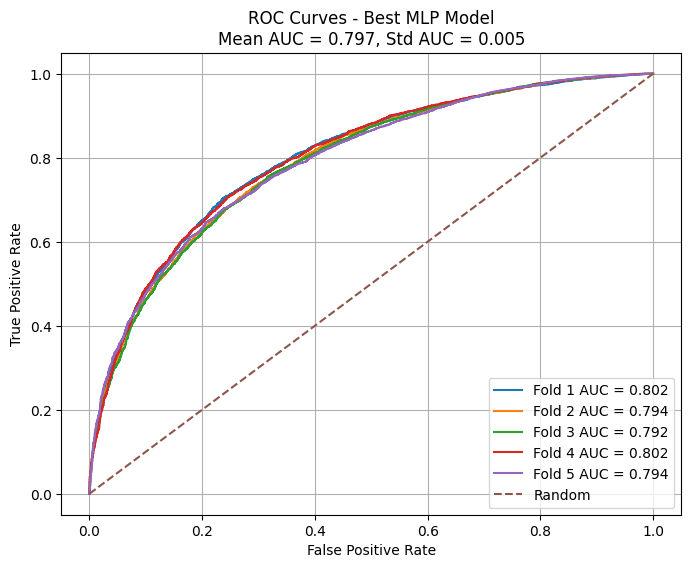

In [23]:
selected_features = ['missing_energy_magnitude', 'jet_1_pt', 'jet_1_b_tag', 'jet_2_pt', 'jet_2_b_tag', 'jet_3_pt',
    'jet_3_b_tag', 'jet_4_pt', 'jet_4_b_tag', 'm_jj', 'm_jjj', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb']

best_params = {'hidden_layer_sizes': (100,), 'activation': 'relu'}

X = df_clean[selected_features]
y = df_clean["label"].astype(int)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []
auc_scores = []

plt.figure(figsize=(8, 6))


for fold, (train_index, test_index) in enumerate(cv.split(X, y), start=1):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = MLPClassifier(
        hidden_layer_sizes=best_params["hidden_layer_sizes"],
        activation=best_params["activation"],
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Fold": fold, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1 Score": f1, "ROC-AUC": roc_auc
    })

    auc_scores.append(roc_auc)

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"Fold {fold} AUC = {roc_auc:.3f}"
    )

mean_auc = np.mean(auc_scores)
std_auc = np.std(auc_scores, ddof=1)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves - Best MLP Model\nMean AUC = {mean_auc:.3f}, Std AUC = {std_auc:.3f}")
plt.legend()
plt.grid()
plt.show()

In [24]:
results_df = pd.DataFrame(results)

auc_summary = pd.DataFrame({
    "Metric": ["Mean ROC-AUC", "Standard Deviation ROC-AUC"],
    "Value": [results_df["ROC-AUC"].mean(), results_df["ROC-AUC"].std()]
})

display(results_df)
display(auc_summary)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,1,0.729116,0.742086,0.770722,0.756133,0.802215
1,2,0.719687,0.736479,0.756228,0.746223,0.793723
2,3,0.716764,0.716065,0.795848,0.753851,0.792105
3,4,0.724847,0.779013,0.691123,0.732441,0.801803
4,5,0.718623,0.734913,0.756532,0.745566,0.794059


,Metric,Value
0,Mean ROC-AUC,0.796781
1,Standard Deviation ROC-AUC,0.004832
